# 데이터 선정 과정 탐색 노트북
## Programmers 크롤링 데이터 검토 → AtCoder 데이터 채택 근거

**프로젝트**: 알고리즘 코딩테스트의 난이도 트렌드 분석  
**목적**: 원래 계획(Programmers/카카오 크롤링)을 실제로 실행해보고,  
왜 해당 데이터가 장기 트렌드 분석에 적합하지 않은지 정량적으로 확인한다.  

---

### 원래 계획 (과제 제안서 기준)
| 데이터 소스 | 역할 |
|------------|------|
| Solved.ac REST API | RQ1 — 난이도 인플레이션 정량 검증 |
| Programmers 크롤링 | 카카오 등 국내 기업 기출 수집 |
| AtCoder Kenkoooo API | 객관 난이도 지표 보조 |

이 노트북은 Programmers 크롤링 경로를 실제로 실행한 결과를 담고 있으며,  
탐색 과정에서 발견된 문제점을 근거로 **AtCoder 단독 활용**으로 범위를 조정한 경위를 기술한다.

## 0. 라이브러리 로드

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams

warnings.filterwarnings('ignore')
rcParams['font.family'] = 'AppleGothic'
rcParams['axes.unicode_minus'] = False

C_PROG    = '#FF6B6B'   # Programmers (카카오) — coral red
C_ATCODER = '#4A90D9'   # AtCoder — steel blue
C_KAKAO   = '#FEE500'   # 카카오 - yellow
C_HYUNDAI = '#005BAC'   # 현대모비스 - blue
C_PROG2   = '#1E9D55'   # 프로그래머스 - green
C_WARN    = '#E84040'   # 기준선 / 경고용 - red

## 1. Programmers 데이터 수집 (`crawl.py` + `clean.py` + `detail.py`)

`crawl.py`는 Playwright를 이용해 `school.programmers.co.kr/learn/challenges` 전 페이지를 순회하며  
문제 제목·레벨·정답률·완료 인원·URL을 수집한다.  

`clean.py`는 수집 결과에서:
1. 출처 텍스트에서 2021–2026 연도를 추출해 범위 밖 행 제거
2. 완료 인원 100명 미만 제거
3. 기업 키워드(카카오/KAKAO, 현대모비스, 프로그래머스) 매칭

`detail.py`는 각 문제 URL을 방문해 지문 순수 글자수를 측정한다.

In [2]:
# 수집·정제 완료 데이터 로드
df = pd.read_csv('../programmers/data/programmers_clean.csv')

print(f'총 수집 문제 수 : {len(df)}개')
print(f'컬럼             : {df.columns.tolist()}')
df.head(5)

총 수집 문제 수 : 60개
컬럼             : ['연도', '기업명', '문제명', '출처', '레벨', '완료한사람', '정답률', 'url', '지문글자수']


,연도,기업명,문제명,출처,레벨,완료한사람,정답률,url,지문글자수
0,2021,카카오,시험장 나누기,2021 카카오 채용연계형 인턴십,Lv. 5,"1,107명",4%,https://school.programmers.co.kr/learn/courses...,2267
1,2021,카카오,미로 탈출,2021 카카오 채용연계형 인턴십,Lv. 4,"1,100명",10%,https://school.programmers.co.kr/learn/courses...,1669
2,2021,카카오,표 편집,2021 카카오 채용연계형 인턴십,Lv. 3,"7,087명",41%,https://school.programmers.co.kr/learn/courses...,2420
3,2021,카카오,거리두기 확인하기,2021 카카오 채용연계형 인턴십,Lv. 2,"16,927명",49%,https://school.programmers.co.kr/learn/courses...,2451
4,2021,카카오,숫자 문자열과 영단어,2021 카카오 채용연계형 인턴십,Lv. 1,"60,445명",73%,https://school.programmers.co.kr/learn/courses...,920


## 2. 탐색적 데이터 분석 — 수집 데이터 현황 파악

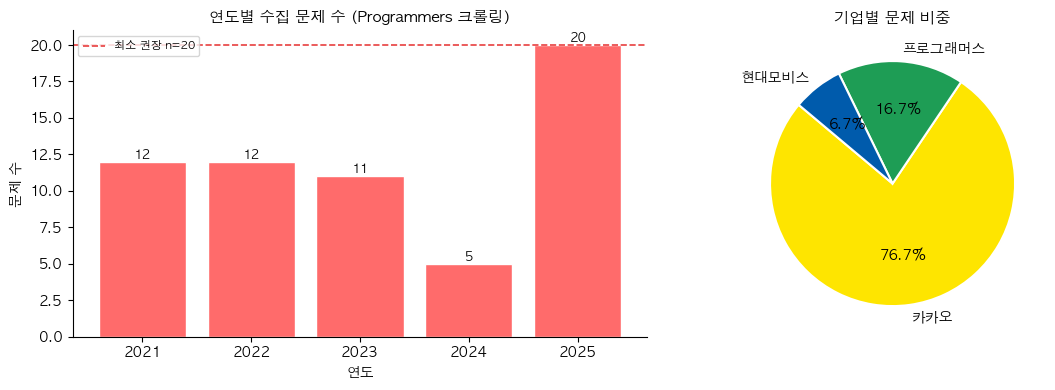


[연도별 문제 수]
연도
2021    12
2022    12
2023    11
2024     5
2025    20

[기업별 문제 수]
기업명
카카오       46
프로그래머스    10
현대모비스      4


In [3]:
# ── 연도별 / 기업별 분포 ──────────────────────────────────────────────────────
year_counts = df['연도'].value_counts().sort_index()
comp_counts = df['기업명'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(year_counts.index.astype(str), year_counts.values,
                   color=C_PROG, edgecolor='white')
axes[0].set_title('연도별 수집 문제 수 (Programmers 크롤링)', fontsize=11)
axes[0].set_xlabel('연도')
axes[0].set_ylabel('문제 수')
axes[0].spines[['top','right']].set_visible(False)
axes[0].axhline(20, color=C_WARN, linewidth=1.2, linestyle='--', label='최소 권장 n=20')
axes[0].legend(fontsize=8)
for bar, v in zip(bars, year_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.2, str(v),
                 ha='center', fontsize=9)

axes[1].pie(comp_counts.values, labels=comp_counts.index,
            autopct='%1.1f%%',
            colors=[C_KAKAO, C_PROG2, C_HYUNDAI],
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('기업별 문제 비중', fontsize=11)

plt.tight_layout()
plt.show()

print('\n[연도별 문제 수]')
print(year_counts.to_string())
print('\n[기업별 문제 수]')
print(comp_counts.to_string())

### 문제점 ① — 샘플 수 부족

연도별 분포를 확인하면:
- 2021년 12개, 2022년 12개, 2023년 11개로 균등해 보이지만,
- **2024년은 5개**에 불과하다.
- 2025년 20개는 프로그래머스 자체 출제(10개)가 포함된 수치로, 순수 카카오 기출은 10개다.

연도별 트렌드를 통계적으로 비교하려면 연도당 최소 20~30개 이상이 필요하다.  
특히 **2024년 n=5**는 한 연도의 대표값을 계산하기에 신뢰도가 매우 낮다.

전체 60개 중 카카오 기출은 46개(76.7%)지만, 이를 5개 연도로 나누면 연평균 9.2개 수준이다.

In [4]:
# ── 카카오 단독 연도별 문제 수 확인 ─────────────────────────────────────────
kakao_by_year = df[df['기업명'] == '카카오']['연도'].value_counts().sort_index()
print('[카카오 단독] 연도별 문제 수')
print(kakao_by_year.to_string())
print(f'\n카카오 연평균 문제 수: {kakao_by_year.mean():.1f}개')
print(f'최소 연도 샘플 수   : {kakao_by_year.min()}개 ({kakao_by_year.idxmin()}년)')

[카카오 단독] 연도별 문제 수
연도
2021    12
2022    12
2023     7
2024     5
2025    10

카카오 연평균 문제 수: 9.2개
최소 연도 샘플 수   : 5개 (2024년)


### 문제점 ② — 알고리즘 태그(유형) 정보 없음

In [5]:
# Programmers 데이터 컬럼 목록 확인
print('[Programmers 수집 컬럼]')
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f'  {col:<18} {non_null}/{len(df)} non-null')

print()
print('→ 알고리즘 유형(태그) 컬럼 없음')
print('  Programmers는 알고리즘 분류 태그를 공개 API로 제공하지 않는다.')

[Programmers 수집 컬럼]
  연도                 60/60 non-null
  기업명                60/60 non-null
  문제명                60/60 non-null
  출처                 60/60 non-null
  레벨                 60/60 non-null
  완료한사람              60/60 non-null
  정답률                60/60 non-null
  url                60/60 non-null
  지문글자수              60/60 non-null

→ 알고리즘 유형(태그) 컬럼 없음
  Programmers는 알고리즘 분류 태그를 공개 API로 제공하지 않는다.


### 문제점 ② 해석

AtCoder AI Tagged API는 문제별 알고리즘 태그(`implementation`, `dp`, `greedy` 등)를 제공하여  
"어떤 유형의 문제가 기업 대회에서 많이 출제되는가"라는 RQ2 분석이 가능하다.

반면 Programmers는 공개 API가 없어 알고리즘 태그를 수집할 수 없다.  
따라서 수집 가능한 정보는 **레벨·정답률·완료인원·지문 길이** 뿐이며,  
알고리즘 유형 트렌드 분석(RQ2)은 수행이 불가능하다.

In [6]:
# ── 레벨 분포 확인 (Programmers가 제공하는 유일한 난이도 지표) ───────────────
def parse_level(text):
    if pd.isna(text): return None
    m = re.search(r'(\d+)', str(text))
    return int(m.group(1)) if m else None

df['레벨_수'] = df['레벨'].apply(parse_level)

level_by_year = (
    df.groupby(['연도', '레벨_수'])['문제명']
    .count()
    .rename('문제수')
    .reset_index()
)
pivot = level_by_year.pivot(index='레벨_수', columns='연도', values='문제수').fillna(0).astype(int)

print('[연도별 레벨 분포]')
print(pivot.to_string())
print()
print('※ Lv. 1~5 외에 알고리즘 유형 정보 없음')
print('  → 구현/DP/그리디 등 태그 기반 트렌드 분석 불가')

[연도별 레벨 분포]
연도    2021  2022  2023  2024  2025
레벨_수                              
1        2     2     1     1     4
2        3     4     2     1     8
3        4     5     5     3     6
4        2     1     2     0     2
5        1     0     1     0     0

※ Lv. 1~5 외에 알고리즘 유형 정보 없음
  → 구현/DP/그리디 등 태그 기반 트렌드 분석 불가


### 문제점 ③ — 저작권 문제 (논문·보고서 활용 부적합)

In [7]:
# 수집된 지문 글자수 확인
df['지문글자수'] = pd.to_numeric(df['지문글자수'], errors='coerce')
crawled = df['지문글자수'].notna().sum()

print(f'지문 수집 성공: {crawled}/{len(df)}개')
print(f'평균 지문 길이: {df["지문글자수"].mean():.0f}자')
print()
print('[저작권 검토 결과]')
print('  - 문제 지문: 기업(카카오 등) 지식재산권 보호 대상')
print('  - 테스트케이스: 별도 지식재산권 보호 대상')
print('  - 수집한 지문 원문을 논문/보고서에 직접 인용·분석하기 부적합')
print('  - 글자수(정수 1개)는 원문 재현이 불가능하므로 통계 지표로만 활용 가능')

지문 수집 성공: 60/60개
평균 지문 길이: 2337자

[저작권 검토 결과]
  - 문제 지문: 기업(카카오 등) 지식재산권 보호 대상
  - 테스트케이스: 별도 지식재산권 보호 대상
  - 수집한 지문 원문을 논문/보고서에 직접 인용·분석하기 부적합
  - 글자수(정수 1개)는 원문 재현이 불가능하므로 통계 지표로만 활용 가능


### 문제점 ③ 해석

`detail.py`로 수집한 **지문 글자수(숫자)**는 원문을 재현할 수 없으므로  
저작권 침해 없이 통계 지표로 활용 가능하다.  
그러나 수집 대상 자체(지문 HTML)는 기업 지식재산권 보호 범위에 포함되며,  
크롤링 코드를 논문의 근거 데이터 수집 파이프라인으로 제시할 경우  
학술적 재현 가능성(reproducibility) 측면에서 문제가 생긴다.

AtCoder는 공식 API와 공개 HTML을 통해 데이터를 제공하며,  
학술 연구 목적 활용이 명시적으로 허용된다.

## 3. Programmers vs AtCoder 데이터 비교

위 세 가지 문제점을 기반으로, 두 데이터 소스를 정량적으로 비교한다.

In [8]:
# ── 비교표 출력 ───────────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    '검토 항목': [
        '총 분석 문제 수',
        '연도별 최소 샘플 수',
        '연도별 평균 샘플 수',
        '알고리즘 태그',
        '객관 난이도 지표',
        '저작권 / 학술 활용',
        '데이터 공개 방식',
        '장기 트렌드 분석',
    ],
    'Programmers 크롤링': [
        f'{len(df)}개 (카카오 46개)',
        f'{kakao_by_year.min()}개 (2024년)',
        f'{kakao_by_year.mean():.1f}개',
        '없음 (공개 API 미제공)',
        '없음 (레벨만 존재, 주관적)',
        '문제 지문 IP 보호 → 부적합',
        '공식 API 없음 → 구조 변경 리스크',
        '불가 (샘플 부족 + 태그 없음)',
    ],
    'AtCoder 기업 스폰서 대회': [
        '644개 전체 → C-F 348개',
        '40개 (2021년)',
        '69.6개',
        'AI 자동 태깅 (API 제공)',
        'Kenkoooo difficulty (객관)',
        '공식 공개 데이터 → 적합',
        '공식 API + 공개 HTML',
        '가능 (2021~2025 5개년)',
    ],
})

comparison

,검토 항목,Programmers 크롤링,AtCoder 기업 스폰서 대회
0,총 분석 문제 수,60개 (카카오 46개),644개 전체 → C-F 348개
1,연도별 최소 샘플 수,5개 (2024년),40개 (2021년)
2,연도별 평균 샘플 수,9.2개,69.6개
3,알고리즘 태그,없음 (공개 API 미제공),AI 자동 태깅 (API 제공)
4,객관 난이도 지표,"없음 (레벨만 존재, 주관적)",Kenkoooo difficulty (객관)
5,저작권 / 학술 활용,문제 지문 IP 보호 → 부적합,공식 공개 데이터 → 적합
6,데이터 공개 방식,공식 API 없음 → 구조 변경 리스크,공식 API + 공개 HTML
7,장기 트렌드 분석,불가 (샘플 부족 + 태그 없음),가능 (2021~2025 5개년)


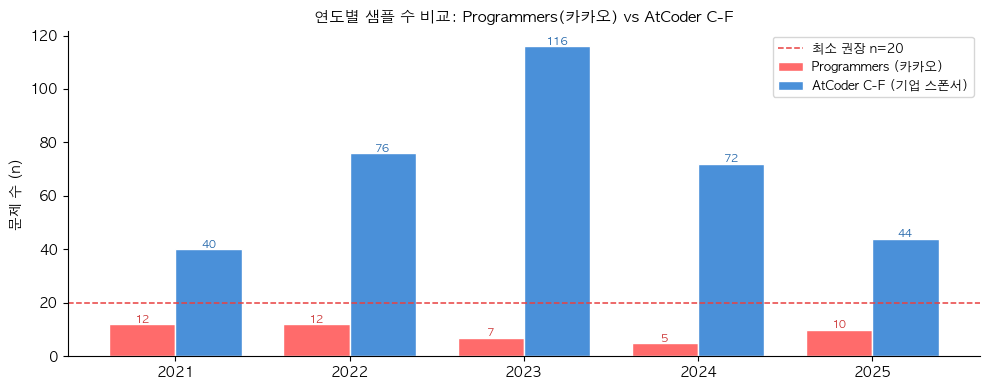

In [9]:
# ── 샘플 수 비교 시각화 ───────────────────────────────────────────────────────
atcoder_by_year = pd.Series({
    2021: 40, 2022: 76, 2023: 116, 2024: 72, 2025: 44
})

x = np.arange(5)
years = [2021, 2022, 2023, 2024, 2025]
prog_vals    = [kakao_by_year.get(y, 0) for y in years]
atcoder_vals = [atcoder_by_year[y] for y in years]

fig, ax = plt.subplots(figsize=(10, 4))
w = 0.38
bars1 = ax.bar(x - w/2, prog_vals,    width=w, label='Programmers (카카오)',
               color=C_PROG,    edgecolor='white')
bars2 = ax.bar(x + w/2, atcoder_vals, width=w, label='AtCoder C-F (기업 스폰서)',
               color=C_ATCODER, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years])
ax.set_ylabel('문제 수 (n)')
ax.set_title('연도별 샘플 수 비교: Programmers(카카오) vs AtCoder C-F', fontsize=11)
ax.axhline(20, color=C_WARN, linewidth=1.1, linestyle='--', label='최소 권장 n=20')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

for bar in bars1:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(int(v)),
            ha='center', fontsize=8, color='#CC3333')
for bar in bars2:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(int(v)),
            ha='center', fontsize=8, color='#2266AA')

plt.tight_layout()
plt.show()

### 샘플 수 비교 해석

- **Programmers(카카오)**: 2024년 n=5로 빨간 기준선(n=20)을 모든 연도에서 하회한다.  
  2025년도 카카오 단독으로는 10개에 불과하다.
- **AtCoder C-F**: 최소 연도(2021)에도 n=40으로 기준선 2배를 확보하며, 2023년 n=116으로 가장 풍부하다.

Programmers 데이터로는 **연도별 통계(평균 지문 길이, 난이도 추세)의 신뢰도**를 보장할 수 없다.  
특히 2024년 n=5로 계산된 평균은 표준오차가 크고 대표성이 낮다.

## 4. 결론 — 연구 범위 조정 결정

Programmers 크롤링 데이터 탐색 결과, 다음 세 가지 이유로 **최종 분석 데이터셋에서 제외**한다.

| 문제점 | 구체적 근거 |
|--------|------------|
| ① 샘플 수 부족 | 카카오 기출 2024년 n=5 — 연도 대표값 산출 불가 |
| ② 알고리즘 태그 없음 | 공개 API 미제공 → RQ2(태그 트렌드 분석) 불가 |
| ③ 저작권 제약 | 문제 지문·테스트케이스 기업 IP 보호 → 학술 재현 리스크 |

대신 **AtCoder 기업 스폰서 대회 데이터**를 합법적·충분한 프록시 데이터로 채택한다.
- 공식 API + 공개 HTML (저작권 문제 없음)
- 2021~2025 C-F 슬롯 348문항 (연도별 40~116개)
- Kenkoooo 객관 난이도 + AI 자동 태그 제공

이 결정은 발표자료 **#3 연구 범위 조정 경위** 슬라이드에 해당한다.

In [10]:
# ── 최종 결정 요약 출력 ───────────────────────────────────────────────────────
decision = pd.DataFrame({
    '항목': ['최종 분석 데이터', '분석 기간', '문제 범위', '총 문제 수',
              '난이도 지표', '유형 지표'],
    '결정': [
        'AtCoder 기업 스폰서 ABC 대회',
        '2021년 ~ 2025년 (5개년)',
        'C–F 슬롯 (중~고난도)',
        '348문항 (87대회, 15개 스폰서)',
        'Kenkoooo difficulty (객관적)',
        'AI Tagged API (알고리즘 태그)',
    ],
    '근거': [
        '저작권 없음, 충분한 샘플',
        'Programmers 대비 5배 샘플',
        '기업 코딩테스트 수준 대응',
        '연도별 최소 n=40 확보',
        '사용자 투표 기반 한계 극복',
        'RQ2 알고리즘 트렌드 분석 가능',
    ]
})
decision

,항목,결정,근거
0,최종 분석 데이터,AtCoder 기업 스폰서 ABC 대회,"저작권 없음, 충분한 샘플"
1,분석 기간,2021년 ~ 2025년 (5개년),Programmers 대비 5배 샘플
2,문제 범위,C–F 슬롯 (중~고난도),기업 코딩테스트 수준 대응
3,총 문제 수,"348문항 (87대회, 15개 스폰서)",연도별 최소 n=40 확보
4,난이도 지표,Kenkoooo difficulty (객관적),사용자 투표 기반 한계 극복
5,유형 지표,AI Tagged API (알고리즘 태그),RQ2 알고리즘 트렌드 분석 가능
